# Phân tích và Mô tả Dữ liệu Online Judge

## Mục tiêu
Notebook này sẽ phân tích chi tiết dữ liệu từ hệ thống online judge để hiểu rõ:
- Cấu trúc và ý nghĩa của từng trường dữ liệu
- Phân phối và đặc điểm của dữ liệu
- Các pattern và insight từ dữ liệu
- Đề xuất các đặc trưng để đánh giá điểm quá trình sinh viên

In [19]:
# Import các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Cấu hình để hiển thị đẹp hơn
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

## 1. Load và Khám phá Dữ liệu Cơ bản

In [20]:
# Load dữ liệu
print("🔄 Đang load dữ liệu...")
annonimized = pd.read_csv('annonimized.csv')
th = pd.read_csv('th-public.csv')

print(f"✅ Đã load thành công!")
print(f"📊 Kích thước dataset chính: {annonimized.shape}")
print(f"📊 Kích thước dataset điểm: {th.shape}")

# Hiển thị thông tin cơ bản
print("\n📋 THÔNG TIN DATASET CHÍNH:")
print("=" * 50)
annonimized.info()

🔄 Đang load dữ liệu...
✅ Đã load thành công!
📊 Kích thước dataset chính: (295198, 11)
📊 Kích thước dataset điểm: (761, 2)

📋 THÔNG TIN DATASET CHÍNH:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 295198 entries, 0 to 295197
Data columns (total 11 columns):
 #   Column                           Non-Null Count   Dtype 
---  ------                           --------------   ----- 
 0   concat('it001',`assignment_id`)  295198 non-null  object
 1   concat('it001',`problem_id`)     295198 non-null  object
 2   concat('it001', username)        295198 non-null  object
 3   is_final                         295198 non-null  int64 
 4   status                           295198 non-null  object
 5   pre_score                        295198 non-null  int64 
 6   coefficient                      295198 non-null  int64 
 7   concat('it001',`language_id`)    295198 non-null  object
 8   created_at                       295198 non-null  object
 9   updated_at                       295198 non-null  ob

## 2. Cấu trúc và Ý nghĩa các Trường Dữ liệu

In [21]:
# Mô tả chi tiết các trường dữ liệu
field_descriptions = {
    "assignment_id": "ID bài tập (đã hash) - Mỗi assignment có nhiều problem",
    "problem_id": "ID bài toán cụ thể (đã hash) - Bài tập con trong assignment", 
    "username": "ID sinh viên (đã hash) - Định danh duy nhất của sinh viên",
    "is_final": "Submission cuối cùng (0/1) - 1 nếu là lần nộp được tính điểm",
    "status": "Trạng thái submission - SCORE/COMPILE_ERROR/RUNTIME_ERROR/...",
    "pre_score": "Điểm thô (0-10000) - 10000 = 100% test case đúng",
    "coefficient": "Hệ số điểm (%) - Phạt nộp muộn, thường 100% nếu đúng hạn",
    "language_id": "Ngôn ngữ lập trình (đã hash) - C/C++/Python/Java/...",
    "created_at": "Thời gian nộp bài - MM-DD HH:MM:SS",
    "updated_at": "Thời gian chấm xong - MM-DD HH:MM:SS", 
    "judgement": "Chi tiết kết quả chấm (JSON) - Thời gian, bộ nhớ, verdict từng test"
}

print("📖 MÔ TẢ CÁC TRƯỜNG DỮ LIỆU:")
print("=" * 70)
for i, (field, desc) in enumerate(field_descriptions.items(), 1):
    print(f"{i:2d}. {field:<15}: {desc}")

# Hiển thị tên cột thực tế
print("\n🏷️  TÊN CỘT THỰC TẾ TRONG DATASET:")
print("=" * 40)
for i, col in enumerate(annonimized.columns, 1):
    print(f"{i:2d}. {col}")

📖 MÔ TẢ CÁC TRƯỜNG DỮ LIỆU:
 1. assignment_id  : ID bài tập (đã hash) - Mỗi assignment có nhiều problem
 2. problem_id     : ID bài toán cụ thể (đã hash) - Bài tập con trong assignment
 3. username       : ID sinh viên (đã hash) - Định danh duy nhất của sinh viên
 4. is_final       : Submission cuối cùng (0/1) - 1 nếu là lần nộp được tính điểm
 5. status         : Trạng thái submission - SCORE/COMPILE_ERROR/RUNTIME_ERROR/...
 6. pre_score      : Điểm thô (0-10000) - 10000 = 100% test case đúng
 7. coefficient    : Hệ số điểm (%) - Phạt nộp muộn, thường 100% nếu đúng hạn
 8. language_id    : Ngôn ngữ lập trình (đã hash) - C/C++/Python/Java/...
 9. created_at     : Thời gian nộp bài - MM-DD HH:MM:SS
10. updated_at     : Thời gian chấm xong - MM-DD HH:MM:SS
11. judgement      : Chi tiết kết quả chấm (JSON) - Thời gian, bộ nhớ, verdict từng test

🏷️  TÊN CỘT THỰC TẾ TRONG DATASET:
 1. concat('it001',`assignment_id`)
 2. concat('it001',`problem_id`)
 3. concat('it001', username)
 4. is_fina

In [22]:
# Đổi tên cột cho dễ hiểu
df = annonimized.copy()
df.columns = [
    "assignment_id", "problem_id", "student", "is_final", "status", 
    "pre_score", "coefficient", "language_id", "created_at", "updated_at", "judgement"
]

print("✅ Đã đổi tên cột thành công!")
print("\n📋 5 DÒNG ĐẦU TIÊN AFTER RENAME:")
print("=" * 50)
df.head()

✅ Đã đổi tên cột thành công!

📋 5 DÒNG ĐẦU TIÊN AFTER RENAME:


,assignment_id,problem_id,student,is_final,status,pre_score,coefficient,language_id,created_at,updated_at,judgement
0,90ce27571176d87961b565d5ef4b3de33ede04ac,789454427dd4097a14749e3dde63346b7a8d3811,ed9eaeb6a707f50154024b24d7efcb874a9795dd,0,SCORE,0,100,it0012,10-09 08:02:04,10-09 08:06:58,"{""times"":[0,0,0,0,0,0,0,0,0,0],""mems"":[0,0,0,0..."
1,90ce27571176d87961b565d5ef4b3de33ede04ac,789454427dd4097a14749e3dde63346b7a8d3811,ed9eaeb6a707f50154024b24d7efcb874a9795dd,0,SCORE,0,100,it0012,10-09 08:04:41,10-09 08:04:51,"{""times"":[0,0,0,0,0,0,0,0,0,0],""mems"":[0,0,0,0..."
2,90ce27571176d87961b565d5ef4b3de33ede04ac,789454427dd4097a14749e3dde63346b7a8d3811,ed9eaeb6a707f50154024b24d7efcb874a9795dd,1,SCORE,10000,100,it0012,10-09 08:06:49,10-09 08:06:58,"{""times"":[0,0,0,0,0,0,0,0,0,0],""mems"":[0,0,0,0..."
3,90ce27571176d87961b565d5ef4b3de33ede04ac,bf96fbdc5f499538c3e2bfbec5779c8a14b0a9ff,ed9eaeb6a707f50154024b24d7efcb874a9795dd,1,SCORE,10000,100,it0012,10-09 08:47:52,10-09 08:48:01,"{""times"":[0,0,0,0,0,0,0,0,0,0],""mems"":[0,0,0,0..."
4,90ce27571176d87961b565d5ef4b3de33ede04ac,7a6e5ca470ff47c3b5048f240c4738de71010c78,ed9eaeb6a707f50154024b24d7efcb874a9795dd,1,SCORE,10000,100,it0012,10-09 09:19:35,10-09 09:19:45,"{""times"":[0,0,0,0,0,0,0,0,0,0],""mems"":[0,0,0,0..."


## 3. Thống kê Mô tả Chi tiết

In [23]:
# Thống kê cơ bản
print("📊 THỐNG KÊ TỔNG QUAN:")
print("=" * 30)
print(f"Tổng số submissions: {len(df):,}")
print(f"Số sinh viên unique: {df['student'].nunique():,}")
print(f"Số bài tập (assignment) unique: {df['assignment_id'].nunique():,}")
print(f"Số problem unique: {df['problem_id'].nunique():,}")
print(f"Số ngôn ngữ lập trình: {df['language_id'].nunique():,}")

# Khoảng thời gian dữ liệu
df['created_at'] = pd.to_datetime(df['created_at'], format='%m-%d %H:%M:%S', errors='coerce')
df['updated_at'] = pd.to_datetime(df['updated_at'], format='%m-%d %H:%M:%S', errors='coerce')

print(f"\n📅 KHOẢNG THỜI GIAN DỮ LIỆU:")
print(f"Từ: {df['created_at'].min()}")
print(f"Đến: {df['created_at'].max()}")
print(f"Thời gian: {(df['created_at'].max() - df['created_at'].min()).days} ngày")

📊 THỐNG KÊ TỔNG QUAN:
Tổng số submissions: 295,198
Số sinh viên unique: 1,489
Số bài tập (assignment) unique: 203


Số problem unique: 469
Số ngôn ngữ lập trình: 6

📅 KHOẢNG THỜI GIAN DỮ LIỆU:
Từ: 1900-01-01 00:13:10
Đến: 1900-12-31 23:53:47
Thời gian: 364 ngày


🎯 PHÂN TÍCH TRẠNG THÁI SUBMISSION:
                   Số lượng  Tỷ lệ (%)
status                                
SCORE                235501      79.78
Compilation Error     59630      20.20
Syntax Error             57       0.02
pending                  10       0.00


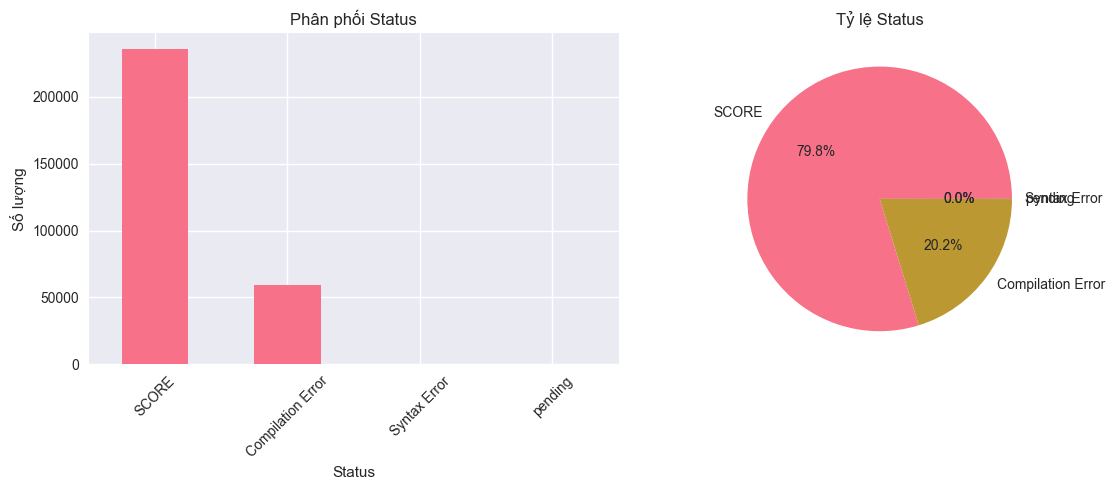

In [24]:
# Phân tích trường status
print("🎯 PHÂN TÍCH TRẠNG THÁI SUBMISSION:")
print("=" * 40)
status_counts = df['status'].value_counts()
status_pct = df['status'].value_counts(normalize=True) * 100

status_df = pd.DataFrame({
    'Số lượng': status_counts,
    'Tỷ lệ (%)': status_pct.round(2)
})
print(status_df)

# Visualize
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
status_counts.plot(kind='bar')
plt.title('Phân phối Status')
plt.xlabel('Status')
plt.ylabel('Số lượng')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%')
plt.title('Tỷ lệ Status')

plt.tight_layout()
plt.show()

In [25]:
# Phân tích điểm số
print("📈 PHÂN TÍCH ĐIỂM SỐ:")
print("=" * 25)

# Chỉ xét những submission có status = SCORE
scored_submissions = df[df['status'] == 'SCORE'].copy()
print(f"Số submission được chấm điểm: {len(scored_submissions):,}")

print("\n📊 Thống kê điểm số (pre_score):")
print(scored_submissions['pre_score'].describe())

# Chuyển đổi sang thang điểm 10
scored_submissions['score_10'] = scored_submissions['pre_score'] / 1000

print("\n📊 Thống kê điểm số (thang 10):")
print(scored_submissions['score_10'].describe())

# Phân loại điểm
score_ranges = {
    'Rất kém (0-2)': (scored_submissions['score_10'] <= 2).sum(),
    'Kém (2-4)': ((scored_submissions['score_10'] > 2) & (scored_submissions['score_10'] <= 4)).sum(),
    'Trung bình (4-6)': ((scored_submissions['score_10'] > 4) & (scored_submissions['score_10'] <= 6)).sum(),
    'Khá (6-8)': ((scored_submissions['score_10'] > 6) & (scored_submissions['score_10'] <= 8)).sum(),
    'Giỏi (8-10)': ((scored_submissions['score_10'] > 8) & (scored_submissions['score_10'] <= 10)).sum(),
    'Hoàn hảo (10)': (scored_submissions['score_10'] == 10).sum()
}

print("\n🎯 PHÂN LOẠI THEO THANG ĐIỂM:")
for range_name, count in score_ranges.items():
    pct = count / len(scored_submissions) * 100
    print(f"{range_name:<20}: {count:>6,} ({pct:5.1f}%)")

📈 PHÂN TÍCH ĐIỂM SỐ:
Số submission được chấm điểm: 235,501

📊 Thống kê điểm số (pre_score):
count    235501.000000
mean       6406.931482
std        3974.252806
min           0.000000
25%        2195.000000
50%        8000.000000
75%       10000.000000
max       10000.000000
Name: pre_score, dtype: float64

📊 Thống kê điểm số (thang 10):
count    235501.000000
mean          6.406931
std           3.974253
min           0.000000
25%           2.195000
50%           8.000000
75%          10.000000
max          10.000000
Name: score_10, dtype: float64

🎯 PHÂN LOẠI THEO THANG ĐIỂM:
Rất kém (0-2)       : 57,936 ( 24.6%)
Kém (2-4)           : 16,277 (  6.9%)
Trung bình (4-6)    : 20,668 (  8.8%)
Khá (6-8)           : 23,317 (  9.9%)
Giỏi (8-10)         : 117,303 ( 49.8%)
Hoàn hảo (10)       : 94,718 ( 40.2%)


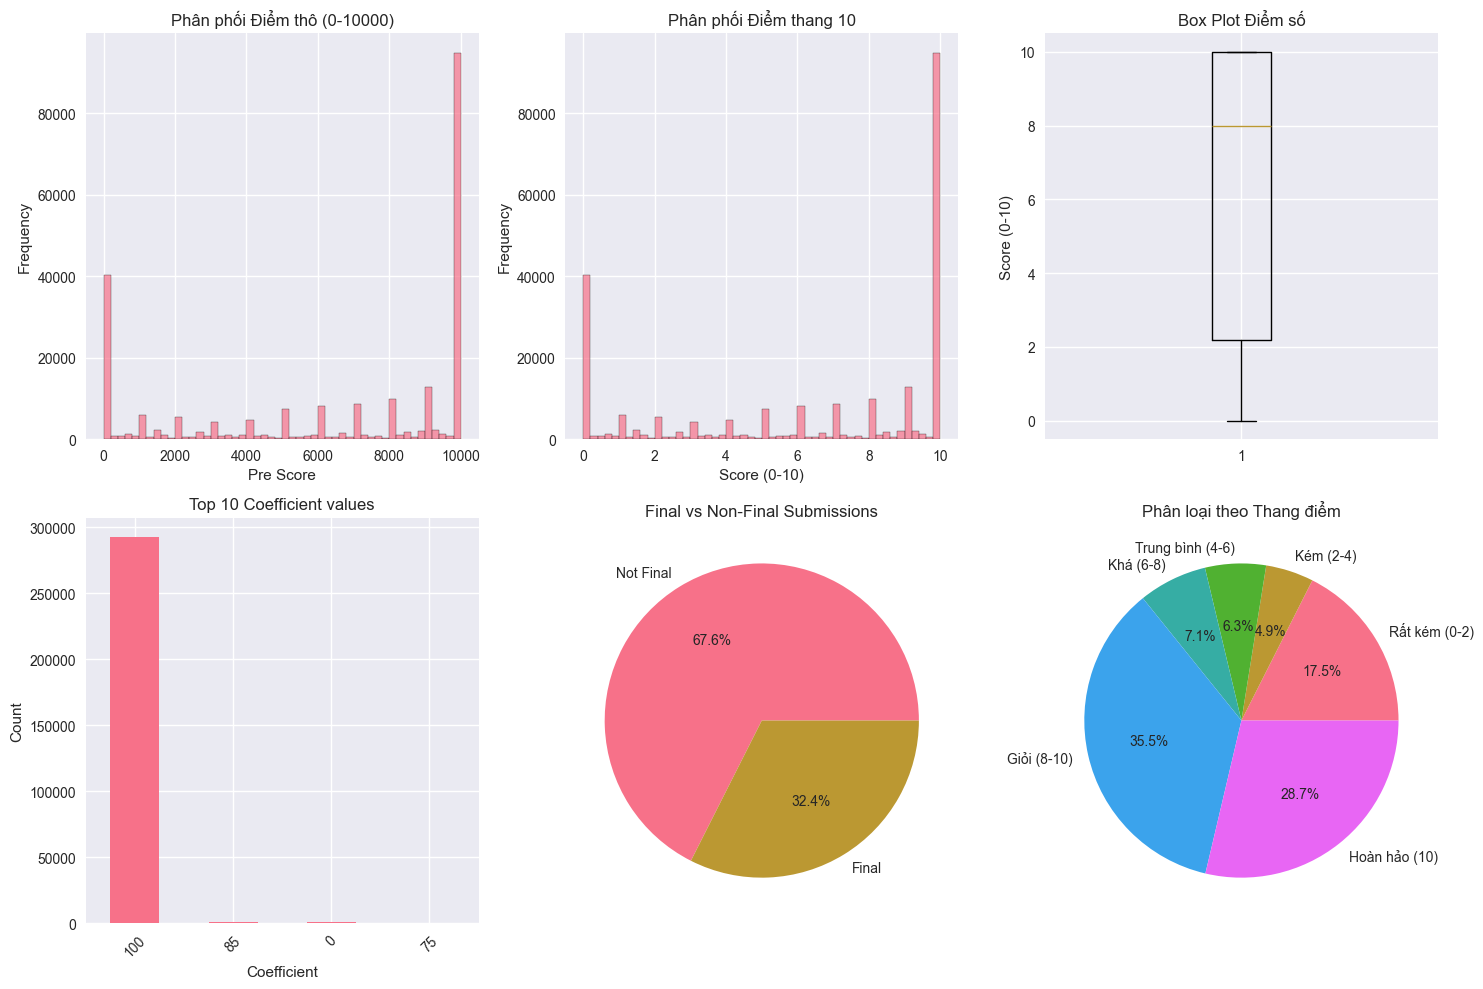

In [26]:
# Visualize phân phối điểm
plt.figure(figsize=(15, 10))

# Histogram điểm thô
plt.subplot(2, 3, 1)
plt.hist(scored_submissions['pre_score'], bins=50, alpha=0.7, edgecolor='black')
plt.title('Phân phối Điểm thô (0-10000)')
plt.xlabel('Pre Score')
plt.ylabel('Frequency')

# Histogram điểm thang 10
plt.subplot(2, 3, 2)
plt.hist(scored_submissions['score_10'], bins=50, alpha=0.7, edgecolor='black')
plt.title('Phân phối Điểm thang 10')
plt.xlabel('Score (0-10)')
plt.ylabel('Frequency')

# Box plot
plt.subplot(2, 3, 3)
plt.boxplot(scored_submissions['score_10'])
plt.title('Box Plot Điểm số')
plt.ylabel('Score (0-10)')

# Phân phối theo coefficient
plt.subplot(2, 3, 4)
coef_counts = df['coefficient'].value_counts().head(10)
coef_counts.plot(kind='bar')
plt.title('Top 10 Coefficient values')
plt.xlabel('Coefficient')
plt.ylabel('Count')
plt.xticks(rotation=45)

# is_final distribution
plt.subplot(2, 3, 5)
final_counts = df['is_final'].value_counts()
plt.pie(final_counts.values, labels=['Not Final', 'Final'], autopct='%1.1f%%')
plt.title('Final vs Non-Final Submissions')

# Score ranges pie chart
plt.subplot(2, 3, 6)
range_values = list(score_ranges.values())
range_labels = list(score_ranges.keys())
plt.pie(range_values, labels=range_labels, autopct='%1.1f%%')
plt.title('Phân loại theo Thang điểm')

plt.tight_layout()
plt.show()

## 4. Phân tích Judgement JSON

In [27]:
# Phân tích trường judgement
print("🔍 PHÂN TÍCH TRƯỜNG JUDGEMENT:")
print("=" * 35)

# Lấy một mẫu judgement để xem cấu trúc
sample_judgement = df['judgement'].iloc[0]
print("📋 Mẫu JSON judgement:")
print(sample_judgement)

try:
    parsed_sample = json.loads(sample_judgement)
    print("\n📊 Cấu trúc JSON đã parse:")
    for key, value in parsed_sample.items():
        print(f"  {key}: {type(value).__name__} - {value}")
except Exception as e:
    print(f"❌ Lỗi parse JSON: {e}")

🔍 PHÂN TÍCH TRƯỜNG JUDGEMENT:
📋 Mẫu JSON judgement:
{"times":[0,0,0,0,0,0,0,0,0,0],"mems":[0,0,0,0,0,0,0,0,0,0],"verdicts":{"WRONG":10}}

📊 Cấu trúc JSON đã parse:
  times: list - [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  mems: list - [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  verdicts: dict - {'WRONG': 10}


In [28]:
# Parse tất cả judgement để phân tích
def parse_judgement_safe(judgement_str):
    """Parse judgement JSON một cách an toàn"""
    try:
        judgement = json.loads(judgement_str)
        return {
            'times': judgement.get('times', []),
            'mems': judgement.get('mems', []),
            'verdicts': judgement.get('verdicts', {}),
            'avg_time': np.mean(judgement.get('times', [0])),
            'max_time': np.max(judgement.get('times', [0])) if judgement.get('times') else 0,
            'avg_memory': np.mean(judgement.get('mems', [0])),
            'max_memory': np.max(judgement.get('mems', [0])) if judgement.get('mems') else 0,
            'num_test_cases': len(judgement.get('times', [])),
            'total_wrong': judgement.get('verdicts', {}).get('WRONG', 0),
            'total_tle': judgement.get('verdicts', {}).get('TLE', 0),
            'total_runtime_error': judgement.get('verdicts', {}).get('RUNTIME_ERROR', 0),
            'total_compile_error': judgement.get('verdicts', {}).get('COMPILE_ERROR', 0)
        }
    except:
        return {
            'times': [], 'mems': [], 'verdicts': {},
            'avg_time': 0, 'max_time': 0, 'avg_memory': 0, 'max_memory': 0,
            'num_test_cases': 0, 'total_wrong': 0, 'total_tle': 0, 
            'total_runtime_error': 0, 'total_compile_error': 0
        }

print("🔄 Đang parse tất cả judgement...")
# Parse một sample nhỏ trước (1000 dòng đầu)
sample_df = df.head(1000).copy()
judgement_features = sample_df['judgement'].apply(parse_judgement_safe)
judgement_parsed_df = pd.DataFrame(list(judgement_features))

print("✅ Đã parse thành công!")
print("\n📊 THỐNG KÊ CÁC VERDICT:")
print("=" * 30)
print(f"Trung bình WRONG per submission: {judgement_parsed_df['total_wrong'].mean():.2f}")
print(f"Trung bình TLE per submission: {judgement_parsed_df['total_tle'].mean():.2f}")
print(f"Trung bình Runtime Error: {judgement_parsed_df['total_runtime_error'].mean():.2f}")
print(f"Trung bình Compile Error: {judgement_parsed_df['total_compile_error'].mean():.2f}")

print("\n⏱️  THỐNG KÊ THỜI GIAN & BỘ NHỚ:")
print("=" * 35)
print(f"Thời gian trung bình: {judgement_parsed_df['avg_time'].mean():.4f}s")
print(f"Thời gian max trung bình: {judgement_parsed_df['max_time'].mean():.4f}s")
print(f"Bộ nhớ trung bình: {judgement_parsed_df['avg_memory'].mean():.0f} KB")
print(f"Số test case trung bình: {judgement_parsed_df['num_test_cases'].mean():.1f}")

🔄 Đang parse tất cả judgement...
✅ Đã parse thành công!

📊 THỐNG KÊ CÁC VERDICT:
Trung bình WRONG per submission: 2.37
Trung bình TLE per submission: 0.00
Trung bình Runtime Error: 0.00
Trung bình Compile Error: 0.00

⏱️  THỐNG KÊ THỜI GIAN & BỘ NHỚ:
Thời gian trung bình: 0.0152s
Thời gian max trung bình: 0.0185s
Bộ nhớ trung bình: 214 KB
Số test case trung bình: 5.3


## 5. Phân tích Thời gian và Pattern

In [29]:
# Phân tích pattern thời gian
df['hour'] = df['created_at'].dt.hour
df['day_of_week'] = df['created_at'].dt.dayofweek  # 0=Monday, 6=Sunday
df['day_name'] = df['created_at'].dt.day_name()
df['processing_time'] = (df['updated_at'] - df['created_at']).dt.total_seconds()

print("🕐 PHÂN TÍCH PATTERN THỜI GIAN:")
print("=" * 35)

# Thống kê theo giờ
hourly_stats = df.groupby('hour').size().sort_index()
print("📊 Số submissions theo giờ (top 5):")
print(hourly_stats.sort_values(ascending=False).head())

# Thống kê theo ngày trong tuần
daily_stats = df.groupby('day_name').size()
print("\n📊 Số submissions theo ngày trong tuần:")
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
for day in day_order:
    if day in daily_stats.index:
        print(f"{day:<10}: {daily_stats[day]:,}")

# Thời gian xử lý
valid_processing_times = df[df['processing_time'].notna() & (df['processing_time'] > 0)]['processing_time']
print(f"\n⏱️  THỜI GIAN XỬ LÝ (giây):")
print(f"Trung bình: {valid_processing_times.mean():.2f}s")
print(f"Median: {valid_processing_times.median():.2f}s")
print(f"Max: {valid_processing_times.max():.2f}s")
print(f"Min: {valid_processing_times.min():.2f}s")

🕐 PHÂN TÍCH PATTERN THỜI GIAN:
📊 Số submissions theo giờ (top 5):
hour
7.0     28754
8.0     28059
15.0    22843
14.0    22508
16.0    19756
dtype: int64

📊 Số submissions theo ngày trong tuần:
Monday    : 32,777
Tuesday   : 59,229
Wednesday : 58,010
Thursday  : 52,385
Friday    : 41,248
Saturday  : 26,230
Sunday    : 25,316

⏱️  THỜI GIAN XỬ LÝ (giây):
Trung bình: 14120.03s
Median: 9.00s
Max: 7556135.00s
Min: 1.00s


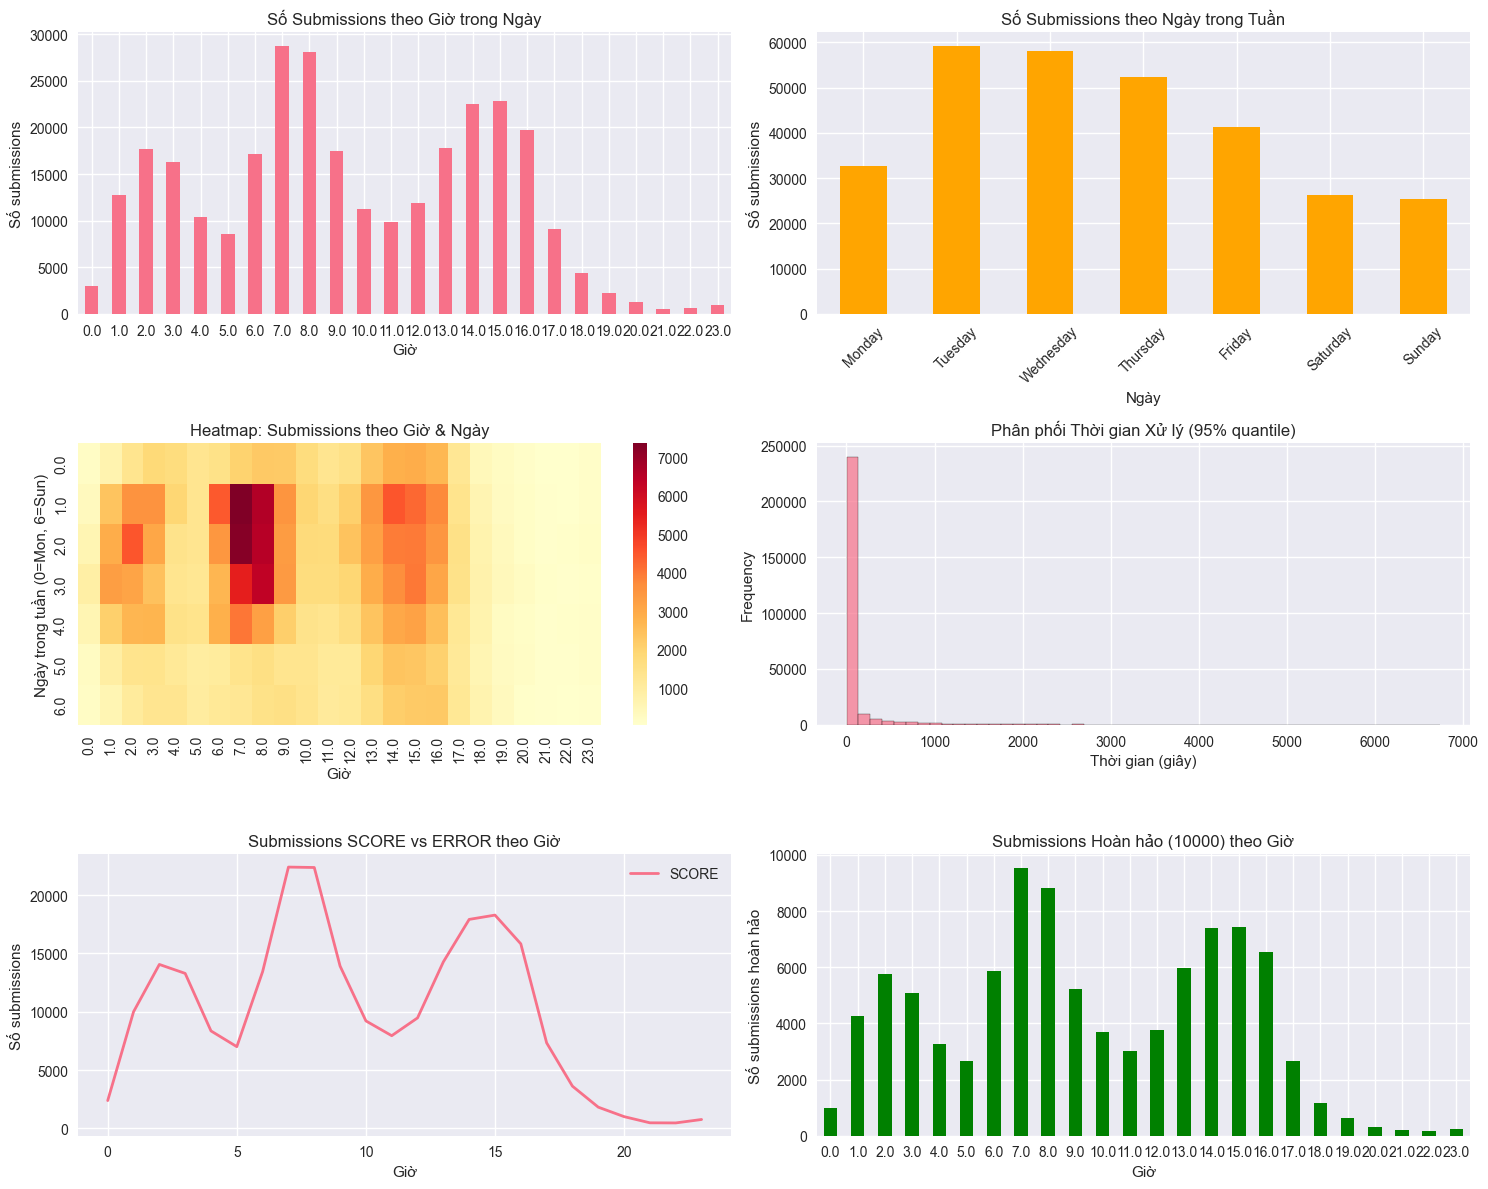

In [30]:
# Visualize time patterns
plt.figure(figsize=(15, 12))

# Submissions theo giờ
plt.subplot(3, 2, 1)
hourly_stats.plot(kind='bar')
plt.title('Số Submissions theo Giờ trong Ngày')
plt.xlabel('Giờ')
plt.ylabel('Số submissions')
plt.xticks(rotation=0)

# Submissions theo ngày trong tuần
plt.subplot(3, 2, 2)
daily_reordered = daily_stats.reindex(day_order)
daily_reordered.plot(kind='bar', color='orange')
plt.title('Số Submissions theo Ngày trong Tuần')
plt.xlabel('Ngày')
plt.ylabel('Số submissions')
plt.xticks(rotation=45)

# Heatmap submissions theo giờ và ngày
plt.subplot(3, 2, 3)
pivot_data = df.groupby(['day_of_week', 'hour']).size().unstack(fill_value=0)
sns.heatmap(pivot_data, cmap='YlOrRd', annot=False)
plt.title('Heatmap: Submissions theo Giờ & Ngày')
plt.ylabel('Ngày trong tuần (0=Mon, 6=Sun)')
plt.xlabel('Giờ')

# Processing time distribution
plt.subplot(3, 2, 4)
# Lọc outliers để visualize tốt hơn
filtered_times = valid_processing_times[valid_processing_times <= valid_processing_times.quantile(0.95)]
plt.hist(filtered_times, bins=50, alpha=0.7, edgecolor='black')
plt.title('Phân phối Thời gian Xử lý (95% quantile)')
plt.xlabel('Thời gian (giây)')
plt.ylabel('Frequency')

# Submissions theo status và giờ
plt.subplot(3, 2, 5)
status_hour = df.groupby(['hour', 'status']).size().unstack(fill_value=0)
status_hour['SCORE'].plot(label='SCORE', linewidth=2)
if 'COMPILE_ERROR' in status_hour.columns:
    status_hour['COMPILE_ERROR'].plot(label='COMPILE_ERROR', linewidth=2)
plt.title('Submissions SCORE vs ERROR theo Giờ')
plt.xlabel('Giờ')
plt.ylabel('Số submissions')
plt.legend()

# Perfect scores theo giờ
plt.subplot(3, 2, 6)
perfect_scores_hourly = df[df['pre_score'] == 10000].groupby('hour').size()
perfect_scores_hourly.plot(kind='bar', color='green')
plt.title('Submissions Hoàn hảo (10000) theo Giờ')
plt.xlabel('Giờ')
plt.ylabel('Số submissions hoàn hảo')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 6. Phân tích Sinh viên và Bài tập

In [31]:
# Phân tích behavior của sinh viên
print("👥 PHÂN TÍCH BEHAVIOR SINH VIÊN:")
print("=" * 40)

# Thống kê cơ bản cho sinh viên
student_stats = df.groupby('student').agg({
    'student': 'count',  # Tổng submissions
    'problem_id': 'nunique',  # Số bài unique
    'assignment_id': 'nunique',  # Số assignment unique
    'pre_score': ['mean', 'max', lambda x: (x == 10000).sum()],  # Điểm TB, max, perfect
    'is_final': 'sum',  # Số lần final
    'status': lambda x: (x == 'SCORE').sum()  # Số lần SCORE
}).round(2)

# Flatten column names
student_stats.columns = [
    'total_submissions', 'unique_problems', 'unique_assignments',
    'avg_score', 'max_score', 'perfect_scores', 'final_submissions', 'successful_submissions'
]

# Tính các tỷ lệ
student_stats['success_rate'] = (student_stats['successful_submissions'] / student_stats['total_submissions']).round(3)
student_stats['perfect_rate'] = (student_stats['perfect_scores'] / student_stats['total_submissions']).round(3)
student_stats['attempts_per_problem'] = (student_stats['total_submissions'] / student_stats['unique_problems']).round(2)

print("📊 Thống kê sinh viên:")
print(student_stats.describe())

print(f"\n🏆 TOP 5 SINH VIÊN CHĂM CHỈ NHẤT (theo số submissions):")
top_active = student_stats.sort_values('total_submissions', ascending=False).head()
for i, (student, row) in enumerate(top_active.iterrows(), 1):
    print(f"{i}. {student[:20]}... - {row['total_submissions']} submissions, {row['unique_problems']} problems")

👥 PHÂN TÍCH BEHAVIOR SINH VIÊN:
📊 Thống kê sinh viên:
       total_submissions  unique_problems  unique_assignments     avg_score  \
count        1489.000000      1489.000000         1489.000000   1489.000000   
mean          198.252518        62.612492            7.232371   5183.794298   
std           133.589121        33.158967            3.774526   1506.981815   
min             1.000000         1.000000            1.000000      0.000000   
25%           107.000000        41.000000            5.000000   4443.610000   
50%           184.000000        62.000000            6.000000   5306.930000   
75%           271.000000        93.000000           10.000000   6086.000000   
max          1047.000000       143.000000           23.000000  10000.000000   

          max_score  perfect_scores  final_submissions  \
count   1489.000000     1489.000000        1489.000000   
mean    9778.321692       63.611820          64.328408   
std     1406.768523       36.292195          34.270022   
mi

In [32]:
# Phân tích độ khó bài tập
print("📚 PHÂN TÍCH ĐỘ KHÓ BÀI TẬP:")
print("=" * 35)

# Thống kê cho từng problem
problem_stats = df.groupby('problem_id').agg({
    'student': 'nunique',  # Số sinh viên thử
    'problem_id': 'count',  # Tổng submissions
    'pre_score': ['mean', lambda x: (x == 10000).sum()],  # Điểm TB, số AC
    'status': lambda x: (x == 'SCORE').sum()  # Số lần SCORE
}).round(2)

problem_stats.columns = ['unique_students', 'total_attempts', 'avg_score', 'perfect_count', 'score_count']

# Tính tỷ lệ AC (Accepted)
problem_stats['ac_rate'] = (problem_stats['perfect_count'] / problem_stats['unique_students']).round(3)
problem_stats['difficulty'] = (1 - problem_stats['ac_rate']).round(3)  # Độ khó = 1 - AC rate
problem_stats['avg_attempts_per_student'] = (problem_stats['total_attempts'] / problem_stats['unique_students']).round(2)

print("📊 Thống kê bài tập:")
print(problem_stats.describe())

print(f"\n😰 TOP 5 BÀI KHÓ NHẤT (AC rate thấp nhất):")
hardest_problems = problem_stats.sort_values('ac_rate').head()
for i, (problem, row) in enumerate(hardest_problems.iterrows(), 1):
    print(f"{i}. {problem[:30]}... - AC rate: {row['ac_rate']:.1%}, {row['unique_students']} students tried")

print(f"\n😊 TOP 5 BÀI DỄ NHẤT (AC rate cao nhất):")
easiest_problems = problem_stats.sort_values('ac_rate', ascending=False).head()
for i, (problem, row) in enumerate(easiest_problems.iterrows(), 1):
    print(f"{i}. {problem[:30]}... - AC rate: {row['ac_rate']:.1%}, {row['unique_students']} students tried")

📚 PHÂN TÍCH ĐỘ KHÓ BÀI TẬP:
📊 Thống kê bài tập:
       unique_students  total_attempts     avg_score  perfect_count  \
count       469.000000      469.000000    469.000000     469.000000   
mean        198.784648      629.420043   5241.425864     201.957356   
std         322.092276     1074.208453   2388.346171     338.024323   
min           1.000000        1.000000      0.000000       0.000000   
25%           4.000000       10.000000   3928.500000       3.000000   
50%          36.000000      102.000000   5260.870000      30.000000   
75%         200.000000      717.000000   6695.970000     192.000000   
max        1157.000000     6580.000000  10000.000000    1266.000000   

       score_count     ac_rate  difficulty  avg_attempts_per_student  
count   469.000000  469.000000  469.000000                469.000000  
mean    502.134328    0.845586    0.154414                  3.031962  
std     871.920957    0.399952    0.399952                  1.626583  
min       0.000000    0.0000

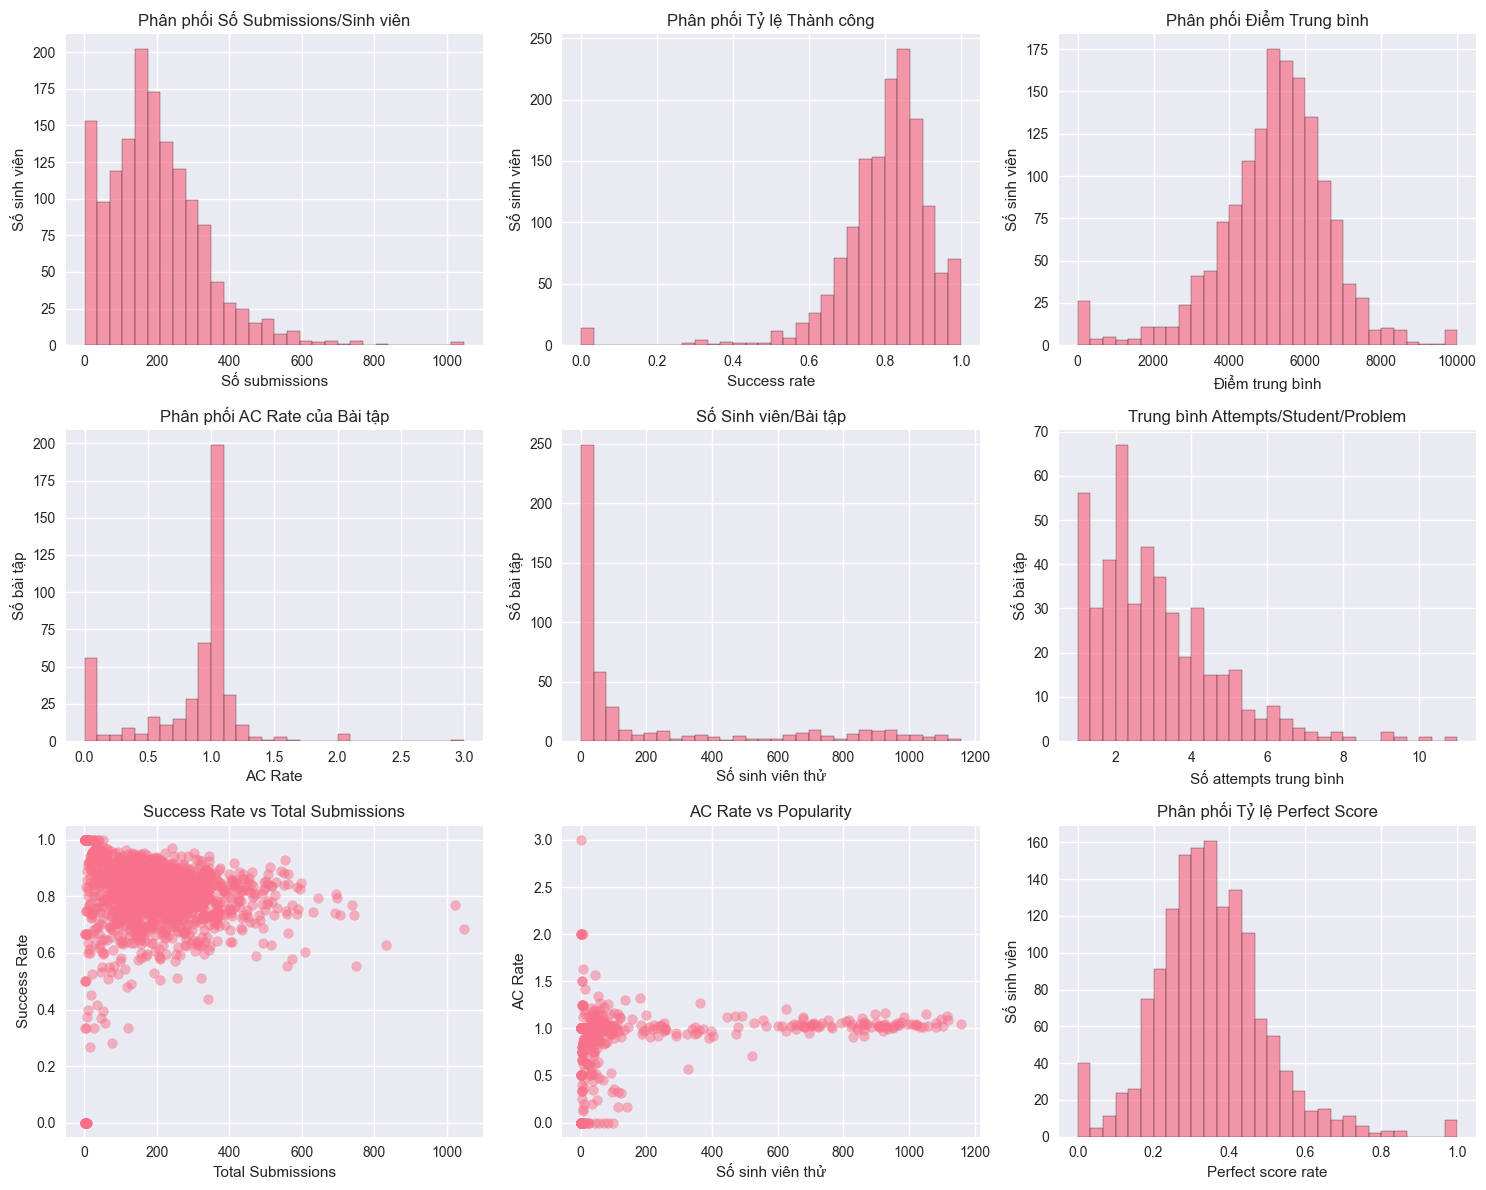

In [33]:
# Visualize student and problem analysis
plt.figure(figsize=(15, 12))

# Distribution of submissions per student
plt.subplot(3, 3, 1)
plt.hist(student_stats['total_submissions'], bins=30, alpha=0.7, edgecolor='black')
plt.title('Phân phối Số Submissions/Sinh viên')
plt.xlabel('Số submissions')
plt.ylabel('Số sinh viên')

# Success rate distribution
plt.subplot(3, 3, 2)
plt.hist(student_stats['success_rate'], bins=30, alpha=0.7, edgecolor='black')
plt.title('Phân phối Tỷ lệ Thành công')
plt.xlabel('Success rate')
plt.ylabel('Số sinh viên')

# Average score distribution
plt.subplot(3, 3, 3)
plt.hist(student_stats['avg_score'], bins=30, alpha=0.7, edgecolor='black')
plt.title('Phân phối Điểm Trung bình')
plt.xlabel('Điểm trung bình')
plt.ylabel('Số sinh viên')

# Problem difficulty distribution
plt.subplot(3, 3, 4)
plt.hist(problem_stats['ac_rate'], bins=30, alpha=0.7, edgecolor='black')
plt.title('Phân phối AC Rate của Bài tập')
plt.xlabel('AC Rate')
plt.ylabel('Số bài tập')

# Students per problem
plt.subplot(3, 3, 5)
plt.hist(problem_stats['unique_students'], bins=30, alpha=0.7, edgecolor='black')
plt.title('Số Sinh viên/Bài tập')
plt.xlabel('Số sinh viên thử')
plt.ylabel('Số bài tập')

# Attempts per problem
plt.subplot(3, 3, 6)
plt.hist(problem_stats['avg_attempts_per_student'], bins=30, alpha=0.7, edgecolor='black')
plt.title('Trung bình Attempts/Student/Problem')
plt.xlabel('Số attempts trung bình')
plt.ylabel('Số bài tập')

# Scatter: Success rate vs Total submissions
plt.subplot(3, 3, 7)
plt.scatter(student_stats['total_submissions'], student_stats['success_rate'], alpha=0.5)
plt.xlabel('Total Submissions')
plt.ylabel('Success Rate')
plt.title('Success Rate vs Total Submissions')

# Scatter: AC rate vs Students attempted
plt.subplot(3, 3, 8)
plt.scatter(problem_stats['unique_students'], problem_stats['ac_rate'], alpha=0.5)
plt.xlabel('Số sinh viên thử')
plt.ylabel('AC Rate')
plt.title('AC Rate vs Popularity')

# Perfect score rate distribution
plt.subplot(3, 3, 9)
plt.hist(student_stats['perfect_rate'], bins=30, alpha=0.7, edgecolor='black')
plt.title('Phân phối Tỷ lệ Perfect Score')
plt.xlabel('Perfect score rate')
plt.ylabel('Số sinh viên')

plt.tight_layout()
plt.show()

## 7. Đề xuất Đặc trưng cho Đánh giá Điểm Quá trình

In [34]:
print("🎯 ĐỀ XUẤT CÁC ĐẶC TRƯNG CHO ĐÁNH GIÁ ĐIỂM QUÁ TRÌNH")
print("=" * 70)

feature_categories = {
    "📊 1. HIỆU SUẤT HỌC TẬP (Performance)": {
        "avg_score": "Điểm trung bình tất cả submissions",
        "max_score": "Điểm cao nhất đạt được",
        "perfect_score_rate": "Tỷ lệ đạt điểm hoàn hảo (10000)",
        "success_rate": "Tỷ lệ submissions có status = SCORE",
        "first_attempt_success_rate": "Tỷ lệ AC ngay lần đầu tiên mỗi bài",
        "score_improvement": "Cải thiện điểm số theo thời gian"
    },
    
    "💪 2. ĐỘ CHĂM CHỈ & KIÊN TRÌ (Effort & Persistence)": {
        "total_submissions": "Tổng số lần nộp bài",
        "unique_problems_attempted": "Số bài tập unique đã thử",
        "avg_attempts_per_problem": "Số lần thử trung bình mỗi bài",
        "active_days": "Số ngày thực sự làm bài",
        "consistency_score": "Tính đều đặn (active_days / total_course_days)",
        "late_night_submissions": "Số lần làm bài đêm khuya (0-6h)",
        "weekend_submissions": "Số lần làm bài cuối tuần"
    },
    
    "🧠 3. KỸ NĂNG LẬP TRÌNH (Programming Skills)": {
        "avg_processing_time": "Thời gian xử lý trung bình (judge time)",
        "avg_execution_time": "Thời gian chạy code trung bình",
        "avg_memory_usage": "Bộ nhớ sử dụng trung bình",
        "compile_error_rate": "Tỷ lệ lỗi compile",
        "runtime_error_rate": "Tỷ lệ lỗi runtime",
        "tle_rate": "Tỷ lệ Time Limit Exceeded"
    },
    
    "🎯 4. KHẢNG NĂNG GIẢI BÀI KHÓ (Problem Solving)": {
        "hard_problems_attempted": "Số bài khó đã thử (AC rate < 30%)",
        "hard_problems_solved": "Số bài khó đã giải được",
        "avg_problem_difficulty": "Độ khó trung bình bài đã làm",
        "max_problem_difficulty": "Bài khó nhất đã thử",
        "hard_problem_success_rate": "Tỷ lệ thành công với bài khó"
    },
    
    "⏰ 5. PATTERN THỜI GIAN (Time Patterns)": {
        "peak_hour_submissions": "Giờ làm bài nhiều nhất",
        "work_time_distribution": "Phân bố thời gian làm việc",
        "early_bird_score": "Điểm cho việc làm bài sớm",
        "deadline_pressure_behavior": "Hành vi khi gần deadline",
        "submission_interval_variance": "Độ đều đặn trong việc submit"
    },
    
    "📈 6. TIẾN BỘ & PHÁT TRIỂN (Progress & Growth)": {
        "weekly_progress": "Tiến bộ theo tuần",
        "learning_curve_slope": "Độ dốc đường cong học tập",
        "problem_complexity_progression": "Tiến triển độ phức tạp bài làm",
        "error_reduction_rate": "Tỷ lệ giảm lỗi theo thời gian",
        "skill_development_trajectory": "Quỹ đạo phát triển kỹ năng"
    }
}

total_features = 0
for category, features in feature_categories.items():
    print(f"\n{category}")
    print("-" * (len(category) - 4))  # Trừ emoji
    for i, (feature, description) in enumerate(features.items(), 1):
        print(f"  {i:2d}. {feature:<35}: {description}")
        total_features += 1

print(f"\n🎊 TỔNG KẾT: {total_features} đặc trưng được đề xuất cho đánh giá điểm quá trình")

🎯 ĐỀ XUẤT CÁC ĐẶC TRƯNG CHO ĐÁNH GIÁ ĐIỂM QUÁ TRÌNH

📊 1. HIỆU SUẤT HỌC TẬP (Performance)
--------------------------------
   1. avg_score                          : Điểm trung bình tất cả submissions
   2. max_score                          : Điểm cao nhất đạt được
   3. perfect_score_rate                 : Tỷ lệ đạt điểm hoàn hảo (10000)
   4. success_rate                       : Tỷ lệ submissions có status = SCORE
   5. first_attempt_success_rate         : Tỷ lệ AC ngay lần đầu tiên mỗi bài
   6. score_improvement                  : Cải thiện điểm số theo thời gian

💪 2. ĐỘ CHĂM CHỈ & KIÊN TRÌ (Effort & Persistence)
----------------------------------------------
   1. total_submissions                  : Tổng số lần nộp bài
   2. unique_problems_attempted          : Số bài tập unique đã thử
   3. avg_attempts_per_problem           : Số lần thử trung bình mỗi bài
   4. active_days                        : Số ngày thực sự làm bài
   5. consistency_score                  : Tính đều đặn

## 8. Công thức Tính Điểm Quá trình Đề xuất

In [35]:
print("🧮 CÔNG THỨC TÍNH ĐIỂM QUÁ TRÌNH ĐỀ XUẤT")
print("=" * 50)

formula_components = {
    "💯 Hiệu suất (40%)": {
        "weight": 0.4,
        "components": {
            "Điểm trung bình": 0.5,
            "Tỷ lệ perfect score": 0.3,
            "Tỷ lệ AC lần đầu": 0.2
        }
    },
    
    "💪 Chăm chỉ & Kiên trì (25%)": {
        "weight": 0.25,
        "components": {
            "Tổng submissions (chuẩn hóa)": 0.3,
            "Tính đều đặn": 0.3,
            "Làm bài ngoài giờ": 0.2,
            "Số attempts/problem": 0.2
        }
    },
    
    "🧠 Kỹ năng lập trình (20%)": {
        "weight": 0.2,
        "components": {
            "Chất lượng code (time/memory)": 0.4,
            "Tỷ lệ lỗi thấp": 0.3,
            "Cải thiện theo thời gian": 0.3
        }
    },
    
    "🎯 Giải bài khó (15%)": {
        "weight": 0.15,
        "components": {
            "Số bài khó giải được": 0.5,
            "Tỷ lệ thành công bài khó": 0.3,
            "Độ khó trung bình": 0.2
        }
    }
}

print("📋 CHI TIẾT CÔNG THỨC:")
print("=" * 25)
total_weight = 0
for category, details in formula_components.items():
    weight = details['weight']
    total_weight += weight
    print(f"\n{category}")
    print(f"  Trọng số: {weight:.0%}")
    print("  Thành phần:")
    for component, comp_weight in details['components'].items():
        print(f"    • {component}: {comp_weight:.0%}")

print(f"\n✅ Tổng trọng số: {total_weight:.0%}")

print("\n🔢 CÔNG THỨC TỔNG QUÁT:")
print("=" * 25)
print("Điểm_Quá_Trình = ")
print("  0.4 × [0.5×avg_score + 0.3×perfect_rate + 0.2×first_attempt_rate] +")
print("  0.25 × [0.3×submissions_norm + 0.3×consistency + 0.2×off_hours + 0.2×persistence] +")
print("  0.2 × [0.4×code_quality + 0.3×low_error_rate + 0.3×improvement] +")
print("  0.15 × [0.5×hard_solved + 0.3×hard_success_rate + 0.2×avg_difficulty]")

print("\n📊 THANG ĐIỂM ĐỀ XUẤT:")
print("=" * 25)
grade_scale = {
    "9.0 - 10.0": "Xuất sắc - Học sinh tích cực, năng lực cao",
    "8.0 - 8.9": "Giỏi - Học sinh chăm chỉ, kỹ năng tốt", 
    "7.0 - 7.9": "Khá - Học sinh ổn định, có tiến bộ",
    "6.0 - 6.9": "Trung bình khá - Cần cải thiện kỹ năng",
    "5.0 - 5.9": "Trung bình - Cần hỗ trợ thêm",
    "< 5.0": "Yếu - Cần can thiệp sớm"
}

for grade_range, description in grade_scale.items():
    print(f"  {grade_range:<12}: {description}")

🧮 CÔNG THỨC TÍNH ĐIỂM QUÁ TRÌNH ĐỀ XUẤT
📋 CHI TIẾT CÔNG THỨC:

💯 Hiệu suất (40%)
  Trọng số: 40%
  Thành phần:
    • Điểm trung bình: 50%
    • Tỷ lệ perfect score: 30%
    • Tỷ lệ AC lần đầu: 20%

💪 Chăm chỉ & Kiên trì (25%)
  Trọng số: 25%
  Thành phần:
    • Tổng submissions (chuẩn hóa): 30%
    • Tính đều đặn: 30%
    • Làm bài ngoài giờ: 20%
    • Số attempts/problem: 20%

🧠 Kỹ năng lập trình (20%)
  Trọng số: 20%
  Thành phần:
    • Chất lượng code (time/memory): 40%
    • Tỷ lệ lỗi thấp: 30%
    • Cải thiện theo thời gian: 30%

🎯 Giải bài khó (15%)
  Trọng số: 15%
  Thành phần:
    • Số bài khó giải được: 50%
    • Tỷ lệ thành công bài khó: 30%
    • Độ khó trung bình: 20%

✅ Tổng trọng số: 100%

🔢 CÔNG THỨC TỔNG QUÁT:
Điểm_Quá_Trình = 
  0.4 × [0.5×avg_score + 0.3×perfect_rate + 0.2×first_attempt_rate] +
  0.25 × [0.3×submissions_norm + 0.3×consistency + 0.2×off_hours + 0.2×persistence] +
  0.2 × [0.4×code_quality + 0.3×low_error_rate + 0.3×improvement] +
  0.15 × [0.5×hard_sol

## 9. Tóm tắt và Kết luận

In [36]:
print("🎯 TÓM TẮT PHÂN TÍCH DỮ LIỆU VÀ ĐỀ XUẤT")
print("=" * 50)

# Tóm tắt insights từ dữ liệu
insights = [
    f"📊 Dataset có {len(df):,} submissions từ {df['student'].nunique():,} sinh viên",
    f"📚 Có {df['problem_id'].nunique():,} bài tập trong {df['assignment_id'].nunique():,} assignments",
    f"⏰ Dữ liệu kéo dài {(df['created_at'].max() - df['created_at'].min()).days} ngày",
    f"✅ Tỷ lệ submissions thành công: {(df['status'] == 'SCORE').mean():.1%}",
    f"🎯 Tỷ lệ perfect score: {(df['pre_score'] == 10000).mean():.1%}",
    f"🕐 Giờ làm bài phổ biến nhất: {hourly_stats.idxmax()}h",
    f"📅 Ngày làm bài nhiều nhất: {daily_stats.idxmax()}"
]

print("\n🔍 INSIGHTS TỪ DỮ LIỆU:")
print("-" * 25)
for insight in insights:
    print(f"  • {insight}")

print("\n💡 CÁC ĐẶC TRƯNG QUAN TRỌNG NHẤT CHO ĐIỂM QUÁ TRÌNH:")
print("-" * 55)
key_features = [
    "1. Điểm trung bình và tỷ lệ perfect score (phản ánh năng lực)",
    "2. Số lượng và tính đều đặn submissions (phản ánh thái độ)",
    "3. Khả năng giải bài khó (phản ánh tư duy)",
    "4. Tỷ lệ AC ngay lần đầu (phản ánh kỹ năng)",
    "5. Cải thiện theo thời gian (phản ánh tiến bộ)",
    "6. Pattern thời gian làm bài (phản ánh sự chăm chỉ)",
    "7. Chất lượng code và tỷ lệ lỗi (phản ánh kỹ thuật)"
]

for feature in key_features:
    print(f"  {feature}")

print("\n🎊 KẾT LUẬN:")
print("-" * 15)
conclusions = [
    "✅ Dữ liệu online judge rất phong phú và có thể đánh giá toàn diện sinh viên",
    "📈 Cần kết hợp nhiều góc độ: hiệu suất, thái độ, kỹ năng, tiến bộ",
    "⚖️  Trọng số hợp lý: Hiệu suất (40%) > Chăm chỉ (25%) > Kỹ năng (20%) > Bài khó (15%)",
    "🔄 Nên cập nhật định kỳ và điều chỉnh theo đặc thù từng lớp/môn học",
    "👨‍🏫 Giúp giáo viên phát hiện sớm sinh viên cần hỗ trợ",
    "🎯 Khuyến khích sinh viên cải thiện thái độ và kỹ năng học tập"
]

for conclusion in conclusions:
    print(f"  {conclusion}")

print("\n" + "=" * 70)
print("          📚 HẾT PHÂN TÍCH - CẢM ƠN BẠN ĐÃ THEO DÕI! 📚          ")
print("=" * 70)

🎯 TÓM TẮT PHÂN TÍCH DỮ LIỆU VÀ ĐỀ XUẤT

🔍 INSIGHTS TỪ DỮ LIỆU:
-------------------------
  • 📊 Dataset có 295,198 submissions từ 1,489 sinh viên
  • 📚 Có 469 bài tập trong 203 assignments
  • ⏰ Dữ liệu kéo dài 364 ngày
  • ✅ Tỷ lệ submissions thành công: 79.8%
  • 🎯 Tỷ lệ perfect score: 32.1%
  • 🕐 Giờ làm bài phổ biến nhất: 7.0h
  • 📅 Ngày làm bài nhiều nhất: Tuesday

💡 CÁC ĐẶC TRƯNG QUAN TRỌNG NHẤT CHO ĐIỂM QUÁ TRÌNH:
-------------------------------------------------------
  1. Điểm trung bình và tỷ lệ perfect score (phản ánh năng lực)
  2. Số lượng và tính đều đặn submissions (phản ánh thái độ)
  3. Khả năng giải bài khó (phản ánh tư duy)
  4. Tỷ lệ AC ngay lần đầu (phản ánh kỹ năng)
  5. Cải thiện theo thời gian (phản ánh tiến bộ)
  6. Pattern thời gian làm bài (phản ánh sự chăm chỉ)
  7. Chất lượng code và tỷ lệ lỗi (phản ánh kỹ thuật)

🎊 KẾT LUẬN:
---------------
  ✅ Dữ liệu online judge rất phong phú và có thể đánh giá toàn diện sinh viên
  📈 Cần kết hợp nhiều góc độ: hiệu suất,